# TCN Hyperparameter Optimization — MOGWO (Multi-Objective Grey Wolf Optimizer)

**Author:** Ibrahim Hanafy  
**Date:** August 2026  
**Objective:** Multi-objective hyperparameter optimization using MOGWO for TCN ECG forecasting.  

**Two Objectives:**
1. Minimize mean RMSE (accuracy)
2. Minimize mean training time (efficiency)

**Search Space (3 params):**
| Parameter | Type | Range |
|-----------|------|-------|
| `n_filters` | categorical | {32, 64, 128, 256} |
| `dropout` | continuous | 0.05–0.40 |
| `lr` | continuous (log) | 1e-4 – 1e-2 |

**Fixed (literature-justified):**
| Parameter | Value | Justification |
|-----------|-------|---------------|
| `n_blocks` | 3 | RF = 1 + 2(3−1)(2³−1) = 29 ≫ lookback=10. 4 blocks (RF=61) was overkill. |
| `kernel_size` | 3 | Bai et al. default. RF already 3× lookback with 3 blocks. |
| `batch_size` | 128 | Low sensitivity once LR tuned. |
| `lookback` | 10 | Matching Dudukcu et al. for fair comparison. |
| `dilation` | [1, 2, 4] | Standard exponential 2^i. |

**MOGWO Config:** 5 wolves × 5 epochs = 25 evaluations  
**Reference:** Mirjalili et al. (2016) — Multi-objective grey wolf optimizer, Expert Systems with Applications 47:106–119

---

## 1 — Imports & Setup

In [1]:
!pip install wfdb -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 5.5 MB/s eta 0:00:00


In [2]:
import os, time, gc, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import wfdb
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')

In [3]:
# ── TensorFlow Setup ─────────────────────────────────────────────────────────
import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Conv1D, Dense, Dropout, Add, Activation, BatchNormalization
)
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print(f'TensorFlow {tf.__version__}')
print(f'GPUs: {tf.config.list_physical_devices("GPU")}')

TensorFlow 2.20.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## 2 — Constants & Configuration

In [4]:
# ── Dataset path ──────────────────────────────────────────────────────────────
DATA_DIR = r"/kaggle/input/datasets/rracer17/mit-bih-mitdb/mit-bih-arrhythmia-database-1.0.0"

# ── Paper constants ───────────────────────────────────────────────────────────
FS           = 360
TOTAL_STEPS  = 100_000
TRAIN_STEPS  = 40_000
VAL_STEPS    = 10_000
TEST_STEPS   = 50_000
LOOKBACK     = 10

# ── Pilot patients for HPO ───────────────────────────────────────────────────
PILOT_PATIENTS = ['100', '103', '108', '119', '124']
PILOT_HORIZON  = 10

# ── Fixed hyperparameters (literature-justified) ─────────────────────────────
FIXED_N_BLOCKS    = 3    # RF = 29 ≫ lookback=10 (was 4, reduced)
FIXED_KERNEL_SIZE = 3    # Bai et al. default
FIXED_BATCH_SIZE  = 128  # Low sensitivity

# ── MOGWO configuration ──────────────────────────────────────────────────────
POP_SIZE     = 5     # wolves per iteration
MAX_ITER     = 5     # MOGWO iterations
ARCHIVE_MAX  = 20    # max Pareto archive size
N_GRIDS      = 10    # grid divisions per objective

# ── Search bounds ────────────────────────────────────────────────────────────
FILTER_OPTIONS = [32, 64, 128, 256]
LB = np.array([0.0, 0.05, -4.0])   # [filter_idx, dropout, log10_lr]
UB = np.array([3.0, 0.40, -2.0])   # [filter_idx, dropout, log10_lr]

# ── Reproducibility ─────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f'MOGWO config: {POP_SIZE} wolves × {MAX_ITER} epochs = {POP_SIZE * MAX_ITER} evals (+ {POP_SIZE} init)')
print(f'Pilot patients: {len(PILOT_PATIENTS)} → {PILOT_PATIENTS}')
print(f'Horizon: H={PILOT_HORIZON}')
print(f'Fixed: n_blocks={FIXED_N_BLOCKS} (RF=29), kernel={FIXED_KERNEL_SIZE}, batch={FIXED_BATCH_SIZE}')
print(f'Search: n_filters∈{FILTER_OPTIONS}, dropout∈[0.05,0.40], lr∈[1e-4,1e-2]')
print(f'Objectives: minimize RMSE, minimize training time')

MOGWO config: 5 wolves × 5 epochs = 25 evals (+ 5 init)
Pilot patients: 5 → ['100', '103', '108', '119', '124']
Horizon: H=10
Fixed: n_blocks=3 (RF=29), kernel=3, batch=128
Search: n_filters∈[32, 64, 128, 256], dropout∈[0.05,0.40], lr∈[1e-4,1e-2]
Objectives: minimize RMSE, minimize training time


## 3 — Data Pipeline

Identical to baseline — load MLII lead, split, normalise, create multi-step sequences.

In [5]:
def load_ecg_signal(record_id, data_dir, n_steps=100_000):
    """Load MLII lead from MIT-BIH, truncate/pad to n_steps."""
    path = os.path.join(data_dir, record_id)
    rec  = wfdb.rdrecord(path)
    sig_names_upper = [s.upper() for s in rec.sig_name]
    ch = sig_names_upper.index('MLII') if 'MLII' in sig_names_upper else 0
    signal = rec.p_signal[:, ch].astype(np.float32)
    if len(signal) < n_steps:
        pad = np.full(n_steps - len(signal), signal[-1], dtype=np.float32)
        signal = np.concatenate([signal, pad])
    return signal[:n_steps]


def preprocess_patient(signal, train_steps=40_000, val_steps=10_000):
    """Split → train/val/test, MinMax-normalise (fit on train only)."""
    train_end = train_steps
    val_end   = train_steps + val_steps
    train_raw = signal[:train_end]
    val_raw   = signal[train_end:val_end]
    test_raw  = signal[val_end:]
    scaler     = MinMaxScaler(feature_range=(0, 1))
    train_norm = scaler.fit_transform(train_raw.reshape(-1, 1)).flatten()
    val_norm   = scaler.transform(val_raw.reshape(-1, 1)).flatten()
    test_norm  = scaler.transform(test_raw.reshape(-1, 1)).flatten()
    return train_norm, val_norm, test_norm, scaler


def make_multistep_sequences(signal, lookback, horizon):
    """X = lookback window, y = next H steps (Multi-Output)."""
    X, y = [], []
    for i in range(len(signal) - lookback - horizon + 1):
        X.append(signal[i : i + lookback])
        y.append(signal[i + lookback : i + lookback + horizon])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


def compute_metrics(y_true, y_pred):
    yt, yp = y_true.flatten(), y_pred.flatten()
    return {
        'RMSE': float(np.sqrt(mean_squared_error(yt, yp))),
        'MAE':  float(mean_absolute_error(yt, yp)),
        'R2':   float(r2_score(yt, yp)),
    }


print('Data pipeline functions defined.')

Data pipeline functions defined.


In [6]:
# ── Load pilot patients only ─────────────────────────────────────────────────
patient_signals = {}

print(f'Loading {len(PILOT_PATIENTS)} pilot patients...\n')
for rid in tqdm(PILOT_PATIENTS, desc='Patients'):
    signal = load_ecg_signal(rid, DATA_DIR, n_steps=TOTAL_STEPS)
    tr, vl, te, sc = preprocess_patient(signal, TRAIN_STEPS, VAL_STEPS)
    patient_signals[rid] = {'train': tr, 'val': vl, 'test': te, 'scaler': sc}
    tqdm.write(f'  Patient {rid:>3s} | train={len(tr):,}  val={len(vl):,}  test={len(te):,}')

print(f'\nAll {len(patient_signals)} pilot patients loaded.')

Loading 5 pilot patients...



Patients:   0%|          | 0/5 [00:00<?, ?it/s]

  Patient 100 | train=40,000  val=10,000  test=50,000
  Patient 103 | train=40,000  val=10,000  test=50,000
  Patient 108 | train=40,000  val=10,000  test=50,000
  Patient 119 | train=40,000  val=10,000  test=50,000
  Patient 124 | train=40,000  val=10,000  test=50,000

All 5 pilot patients loaded.


## 4 — Model Architecture

Same residual block as baseline. **Changed: n_blocks=3** (was 4).  
RF = 1 + 2(3−1)(2³−1) = 29 — still 3× the lookback of 10.

In [7]:
def residual_block(x, filters, kernel_size, dilation_rate, dropout_rate):
    out = Conv1D(filters, kernel_size, dilation_rate=dilation_rate, padding='causal')(x)
    out = BatchNormalization()(out)
    out = Activation('relu')(out)
    out = Dropout(dropout_rate)(out)
    out = Conv1D(filters, kernel_size, dilation_rate=dilation_rate, padding='causal')(out)
    out = BatchNormalization()(out)
    out = Activation('relu')(out)
    out = Dropout(dropout_rate)(out)
    if x.shape[-1] != filters:
        x = Conv1D(filters, 1)(x)
    return Add()([x, out])


def build_tcn(lookback, output_size, n_blocks, n_filters, kernel_size, dropout_rate, learning_rate):
    """Build TCN with explicit hyperparameters."""
    inp = Input(shape=(lookback, 1))
    x = inp
    for i in range(n_blocks):
        x = residual_block(x, n_filters, kernel_size, 2 ** i, dropout_rate)
    x = x[:, -1, :]  # last time-step
    x = Dense(n_filters, activation='relu')(x)
    out = Dense(output_size)(x)
    model = Model(inp, out, name=f'TCN_out{output_size}')
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate), loss='mse')
    return model


# Quick sanity check — parameter count comparison
demo_3 = build_tcn(10, 10, 3, 64, 3, 0.1, 0.001)
demo_4 = build_tcn(10, 10, 4, 64, 3, 0.1, 0.001)
print(f'3 blocks, 64 filters: {demo_3.count_params():,} params')
print(f'4 blocks, 64 filters: {demo_4.count_params():,} params')
print(f'Reduction: {(1 - demo_3.count_params()/demo_4.count_params())*100:.1f}%')
del demo_3, demo_4
print('\nModel architecture defined.')

I0000 00:00:1786877162.587443      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1786877162.590556      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


3 blocks, 64 filters: 68,490 params
4 blocks, 64 filters: 93,706 params
Reduction: 26.9%

Model architecture defined.


## 5 — MOGWO Implementation

Custom implementation following Mirjalili et al. (2016), Section 3 & Fig. 2.

**Key components:**
- **Archive**: stores non-dominated (Pareto-optimal) solutions
- **Grid mechanism**: divides objective space into cells for diversity
- **Leader selection**: picks α, β, δ from least-crowded archive cells via roulette wheel
- **Position update**: GWO equations (3.5–3.11) with `a` decreasing 2→0

In [8]:
class MOGWO:
    """
    Multi-Objective Grey Wolf Optimizer.
    Reference: Mirjalili et al. (2016), Expert Systems with Applications 47:106-119.
    """

    def __init__(self, n_wolves, max_iter, n_obj, lb, ub,
                 archive_max=20, n_grids=10, seed=None):
        self.n_wolves = n_wolves
        self.max_iter = max_iter
        self.n_obj = n_obj
        self.lb = np.array(lb, dtype=np.float64)
        self.ub = np.array(ub, dtype=np.float64)
        self.n_dim = len(lb)
        self.archive_max = archive_max
        self.n_grids = n_grids
        if seed is not None:
            np.random.seed(seed)

        # Archive storage
        self.archive_solutions = np.empty((0, self.n_dim))
        self.archive_objectives = np.empty((0, self.n_obj))

        # Grid boundaries (updated dynamically)
        self.grid_min = np.zeros(self.n_obj)
        self.grid_max = np.ones(self.n_obj)

    # ── Pareto Dominance (Def. 1 in paper) ───────────────────────────────────
    @staticmethod
    def dominates(obj_a, obj_b):
        """Check if a dominates b (all objectives minimised)."""
        return np.all(obj_a <= obj_b) and np.any(obj_a < obj_b)

    def get_non_dominated(self, objectives):
        """Return indices of non-dominated solutions."""
        n = len(objectives)
        is_dominated = np.zeros(n, dtype=bool)
        for i in range(n):
            if is_dominated[i]:
                continue
            for j in range(n):
                if i == j or is_dominated[j]:
                    continue
                if self.dominates(objectives[j], objectives[i]):
                    is_dominated[i] = True
                    break
        return np.where(~is_dominated)[0]

    # ── Archive Management ────────────────────────────────────────────────────
    def update_archive(self, new_solutions, new_objectives):
        """Add non-dominated solutions to archive, remove dominated ones."""
        # Combine archive + new solutions
        if len(self.archive_solutions) > 0:
            all_sol = np.vstack([self.archive_solutions, new_solutions])
            all_obj = np.vstack([self.archive_objectives, new_objectives])
        else:
            all_sol = new_solutions.copy()
            all_obj = new_objectives.copy()

        # Keep only non-dominated
        nd_idx = self.get_non_dominated(all_obj)
        self.archive_solutions = all_sol[nd_idx].copy()
        self.archive_objectives = all_obj[nd_idx].copy()

        # Handle overflow — remove from most crowded cell
        while len(self.archive_solutions) > self.archive_max:
            cell_map = self._get_cell_map()
            most_crowded = max(cell_map, key=lambda k: len(cell_map[k]))
            remove_idx = np.random.choice(cell_map[most_crowded])
            mask = np.ones(len(self.archive_solutions), dtype=bool)
            mask[remove_idx] = False
            self.archive_solutions = self.archive_solutions[mask]
            self.archive_objectives = self.archive_objectives[mask]

        # Update grid boundaries
        self._update_grid_bounds()

    # ── Grid Mechanism (Section 3 in paper) ──────────────────────────────────
    def _update_grid_bounds(self):
        """Update grid boundaries based on current archive extent."""
        if len(self.archive_objectives) == 0:
            return
        self.grid_min = self.archive_objectives.min(axis=0)
        self.grid_max = self.archive_objectives.max(axis=0)
        # Add 10% margin to avoid edge issues
        margin = (self.grid_max - self.grid_min) * 0.1
        margin = np.where(margin == 0, 0.1, margin)
        self.grid_min -= margin
        self.grid_max += margin

    def _get_grid_indices(self):
        """Get grid cell index for each archive member."""
        rng = self.grid_max - self.grid_min
        rng = np.where(rng == 0, 1.0, rng)  # avoid division by zero
        normalised = (self.archive_objectives - self.grid_min) / rng
        indices = np.floor(normalised * self.n_grids).astype(int)
        return np.clip(indices, 0, self.n_grids - 1)

    def _get_cell_map(self):
        """Map grid cell → list of archive member indices."""
        grid_idx = self._get_grid_indices()
        cell_map = {}
        for i, gi in enumerate(grid_idx):
            key = tuple(gi)
            if key not in cell_map:
                cell_map[key] = []
            cell_map[key].append(i)
        return cell_map

    # ── Leader Selection (Eq. 3.12 in paper) ─────────────────────────────────
    def select_leader(self, exclude_indices=None):
        """
        Select leader from archive via roulette wheel on least-crowded cells.
        P_i = c / N_i  (Eq. 3.12) — less crowded cells have higher probability.
        """
        if exclude_indices is None:
            exclude_indices = []

        n_archive = len(self.archive_solutions)
        if n_archive == 0:
            raise ValueError('Archive is empty')

        # Available indices (not excluded)
        available = [i for i in range(n_archive) if i not in exclude_indices]
        if len(available) == 0:
            # All excluded — pick any (paper: handles < 3 archive members)
            return np.random.randint(n_archive)

        # Grid-based probabilities
        cell_map = self._get_cell_map()
        probs = np.zeros(n_archive)
        for cell_key, members in cell_map.items():
            n_i = len(members)
            for idx in members:
                probs[idx] = 1.0 / n_i  # P_i = c/N_i with c=1

        # Zero out excluded
        for ei in exclude_indices:
            if ei < n_archive:
                probs[ei] = 0.0

        # Normalise
        total = probs.sum()
        if total == 0:
            probs[available] = 1.0
            total = probs.sum()
        probs /= total

        return np.random.choice(n_archive, p=probs)

    # ── Main Optimisation Loop (Fig. 2 pseudocode) ───────────────────────────
    def solve(self, obj_func, verbose=True):
        """
        Run MOGWO optimisation.

        Parameters
        ----------
        obj_func : callable
            Takes solution vector, returns np.array of shape (n_obj,).
        verbose : bool
            Print progress.

        Returns
        -------
        archive_solutions : np.ndarray — Pareto-optimal solution vectors
        archive_objectives : np.ndarray — corresponding objective values
        eval_log : list[dict] — full evaluation history
        """
        eval_log = []

        # ── Step 1: Initialise wolf population randomly ──────────────────────
        wolves = np.random.uniform(self.lb, self.ub, (self.n_wolves, self.n_dim))
        objectives = np.zeros((self.n_wolves, self.n_obj))

        if verbose:
            print(f'\n{"="*70}')
            print(f'MOGWO Initialisation — Evaluating {self.n_wolves} wolves')
            print(f'{"="*70}')

        # ── Step 2: Evaluate initial population ──────────────────────────────
        for i in range(self.n_wolves):
            objectives[i] = obj_func(wolves[i])
            eval_log.append({
                'iteration': 0, 'wolf': i,
                'solution': wolves[i].copy(),
                'objectives': objectives[i].copy(),
            })

        # ── Step 3: Initialise archive with non-dominated solutions ──────────
        self.update_archive(wolves, objectives)

        if verbose:
            print(f'\nArchive after init: {len(self.archive_solutions)} solutions')

        # ── Step 4: Main iteration loop ──────────────────────────────────────
        for t in range(1, self.max_iter + 1):
            # a decreases linearly from 2 to 0 (controls exploration/exploitation)
            a = 2.0 - t * (2.0 / self.max_iter)

            # Select leaders from archive (α, β, δ)
            alpha_idx = self.select_leader()
            beta_idx  = self.select_leader(exclude_indices=[alpha_idx])
            delta_idx = self.select_leader(exclude_indices=[alpha_idx, beta_idx])

            X_alpha = self.archive_solutions[alpha_idx]
            X_beta  = self.archive_solutions[beta_idx]
            X_delta = self.archive_solutions[delta_idx]

            if verbose:
                print(f'\n{"="*70}')
                print(f'MOGWO Iteration {t}/{self.max_iter} — a={a:.3f}')
                print(f'{"="*70}')

            # Update each wolf's position (Eq. 3.5–3.11)
            for i in range(self.n_wolves):
                # Random coefficients for α
                r1, r2 = np.random.random(self.n_dim), np.random.random(self.n_dim)
                A1 = 2.0 * a * r1 - a    # Eq. 3.3
                C1 = 2.0 * r2             # Eq. 3.4

                # Random coefficients for β
                r1, r2 = np.random.random(self.n_dim), np.random.random(self.n_dim)
                A2 = 2.0 * a * r1 - a
                C2 = 2.0 * r2

                # Random coefficients for δ
                r1, r2 = np.random.random(self.n_dim), np.random.random(self.n_dim)
                A3 = 2.0 * a * r1 - a
                C3 = 2.0 * r2

                # Distance vectors (Eq. 3.5–3.7)
                D_alpha = np.abs(C1 * X_alpha - wolves[i])
                D_beta  = np.abs(C2 * X_beta  - wolves[i])
                D_delta = np.abs(C3 * X_delta - wolves[i])

                # Position candidates (Eq. 3.8–3.10)
                X1 = X_alpha - A1 * D_alpha
                X2 = X_beta  - A2 * D_beta
                X3 = X_delta - A3 * D_delta

                # New position = average (Eq. 3.11)
                wolves[i] = (X1 + X2 + X3) / 3.0

                # Clip to search bounds
                wolves[i] = np.clip(wolves[i], self.lb, self.ub)

            # Evaluate updated population
            for i in range(self.n_wolves):
                objectives[i] = obj_func(wolves[i])
                eval_log.append({
                    'iteration': t, 'wolf': i,
                    'solution': wolves[i].copy(),
                    'objectives': objectives[i].copy(),
                })

            # Update archive
            self.update_archive(wolves, objectives)

            if verbose:
                print(f'Archive size: {len(self.archive_solutions)}')
                print(f'RMSE  range: [{self.archive_objectives[:,0].min():.6f}, '
                      f'{self.archive_objectives[:,0].max():.6f}]')
                print(f'Time  range: [{self.archive_objectives[:,1].min():.1f}s, '
                      f'{self.archive_objectives[:,1].max():.1f}s]')

        return self.archive_solutions.copy(), self.archive_objectives.copy(), eval_log


print('MOGWO class defined.')

MOGWO class defined.


## 6 — Objective Function

**Returns two values:** `[mean_RMSE, mean_time]`  
- Train on train split, early-stop on val split, evaluate RMSE on test split  
- Time = wall-clock seconds for fit + predict per patient, averaged

In [9]:
# Track all evaluations for analysis
mogwo_eval_log = []


def objective(solution):
    """
    MOGWO objective: decode solution → train TCN on pilot patients
    → return [mean_RMSE, mean_time].
    """
    # ── Decode solution vector ────────────────────────────────────────────────
    filter_idx = int(np.clip(np.round(solution[0]), 0, 3))
    n_filters  = FILTER_OPTIONS[filter_idx]
    dropout    = float(np.clip(solution[1], 0.05, 0.40))
    lr         = float(10 ** np.clip(solution[2], -4, -2))  # log10 scale

    eval_id = len(mogwo_eval_log) + 1
    print(f'  [Eval {eval_id:3d}] filters={n_filters:>3d}, '
          f'dropout={dropout:.3f}, lr={lr:.6f}', end=' ')

    rmse_scores = []
    time_scores = []

    for pid in PILOT_PATIENTS:
        tf.keras.backend.clear_session()
        gc.collect()

        tr = patient_signals[pid]['train']
        vl = patient_signals[pid]['val']
        te = patient_signals[pid]['test']

        X_tr, y_tr = make_multistep_sequences(tr, LOOKBACK, PILOT_HORIZON)
        X_vl, y_vl = make_multistep_sequences(vl, LOOKBACK, PILOT_HORIZON)
        X_te, y_te = make_multistep_sequences(te, LOOKBACK, PILOT_HORIZON)

        X_tr_r = X_tr.reshape(-1, X_tr.shape[1], 1)
        X_vl_r = X_vl.reshape(-1, X_vl.shape[1], 1)
        X_te_r = X_te.reshape(-1, X_te.shape[1], 1)

        model = build_tcn(LOOKBACK, PILOT_HORIZON,
                          FIXED_N_BLOCKS, n_filters, FIXED_KERNEL_SIZE,
                          dropout, lr)

        t0 = time.time()
        history = model.fit(
            X_tr_r, y_tr,
            validation_data=(X_vl_r, y_vl),
            epochs=100,
            batch_size=FIXED_BATCH_SIZE,
            callbacks=[
                EarlyStopping(monitor='val_loss', patience=20,
                              restore_best_weights=True),
                ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                  patience=10, min_lr=1e-6),
            ],
            verbose=0
        )
        preds = model.predict(X_te_r, batch_size=2048, verbose=0)
        elapsed = time.time() - t0

        rmse = float(np.sqrt(mean_squared_error(y_te.flatten(), preds.flatten())))
        rmse_scores.append(rmse)
        time_scores.append(elapsed)

        del model
        gc.collect()

    mean_rmse = float(np.mean(rmse_scores))
    mean_time = float(np.mean(time_scores))

    print(f'→ RMSE={mean_rmse:.6f}, Time={mean_time:.1f}s')

    mogwo_eval_log.append({
        'eval': eval_id,
        'n_filters': n_filters,
        'dropout': round(dropout, 4),
        'lr': round(lr, 8),
        'mean_rmse': mean_rmse,
        'mean_time': round(mean_time, 2),
    })

    return np.array([mean_rmse, mean_time])


print('Objective function defined.')
print(f'Each eval trains on {len(PILOT_PATIENTS)} patients × H={PILOT_HORIZON}')
print(f'Fixed: n_blocks={FIXED_N_BLOCKS}, kernel={FIXED_KERNEL_SIZE}, batch={FIXED_BATCH_SIZE}')
print(f'Returns: [mean_RMSE, mean_time]')

Objective function defined.
Each eval trains on 5 patients × H=10
Fixed: n_blocks=3, kernel=3, batch=128
Returns: [mean_RMSE, mean_time]


## 7 — Run MOGWO Search

**Budget:** 5 wolves × (1 init + 5 iterations) = 30 evaluations  
**Estimated time:** ~4–8 hours on 2×T4

In [10]:
# ┌──────────────────────────────────────────────────────────────────────────┐
# │  RUN MOGWO SEARCH                                                      │
# └──────────────────────────────────────────────────────────────────────────┘

print(f'MOGWO config: {POP_SIZE} wolves × {MAX_ITER} iterations')
print(f'Expected total evaluations: {POP_SIZE * (1 + MAX_ITER)}')
print(f'Archive max: {ARCHIVE_MAX}, Grid divisions: {N_GRIDS}')
print()

optimizer = MOGWO(
    n_wolves=POP_SIZE,
    max_iter=MAX_ITER,
    n_obj=2,           # RMSE, time
    lb=LB,
    ub=UB,
    archive_max=ARCHIVE_MAX,
    n_grids=N_GRIDS,
    seed=SEED,
)

t_start = time.time()
archive_solutions, archive_objectives, eval_history = optimizer.solve(
    obj_func=objective,
    verbose=True,
)
total_time = time.time() - t_start

print(f'\n{"="*70}')
print(f'MOGWO Search Complete!')
print(f'  Total time        : {total_time/60:.1f} min ({total_time/3600:.1f} hrs)')
print(f'  Total evaluations : {len(mogwo_eval_log)}')
print(f'  Archive size      : {len(archive_solutions)}')
print(f'{"="*70}')

MOGWO config: 5 wolves × 5 iterations
Expected total evaluations: 30
Archive max: 20, Grid divisions: 10


MOGWO Initialisation — Evaluating 5 wolves
  [Eval   1] filters= 64, dropout=0.383, lr=0.002911 

I0000 00:00:1786877176.672713      78 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


→ RMSE=0.031217, Time=134.5s
  [Eval   2] filters=128, dropout=0.105, lr=0.000205 → RMSE=0.028615, Time=161.7s
  [Eval   3] filters= 32, dropout=0.353, lr=0.001593 → RMSE=0.034103, Time=138.4s
  [Eval   4] filters=128, dropout=0.057, lr=0.008706 → RMSE=0.028631, Time=138.5s
  [Eval   5] filters=128, dropout=0.124, lr=0.000231 → RMSE=0.029771, Time=153.3s

Archive after init: 3 solutions

MOGWO Iteration 1/5 — a=1.600
  [Eval   6] filters= 64, dropout=0.234, lr=0.010000 → RMSE=0.029000, Time=152.2s
  [Eval   7] filters=128, dropout=0.170, lr=0.001109 → RMSE=0.028466, Time=146.8s
  [Eval   8] filters=256, dropout=0.050, lr=0.010000 → RMSE=0.027583, Time=235.4s
  [Eval   9] filters=128, dropout=0.050, lr=0.000167 → RMSE=0.027860, Time=161.5s
  [Eval  10] filters=128, dropout=0.084, lr=0.001705 → RMSE=0.028388, Time=141.7s
Archive size: 5
RMSE  range: [0.027583, 0.031217]
Time  range: [134.5s, 235.4s]

MOGWO Iteration 2/5 — a=1.200
  [Eval  11] filters=256, dropout=0.050, lr=0.003809 → RMS

## 8 — Analysis & Visualisation

In [11]:
# ── 8.1 Decode archive solutions ─────────────────────────────────────────────
archive_decoded = []
for sol, obj in zip(archive_solutions, archive_objectives):
    filter_idx = int(np.clip(np.round(sol[0]), 0, 3))
    archive_decoded.append({
        'n_filters': FILTER_OPTIONS[filter_idx],
        'dropout': round(float(np.clip(sol[1], 0.05, 0.40)), 4),
        'lr': round(float(10 ** np.clip(sol[2], -4, -2)), 8),
        'RMSE': round(obj[0], 6),
        'Time_s': round(obj[1], 2),
    })

df_archive = pd.DataFrame(archive_decoded).sort_values('RMSE')
print(f'Pareto Archive — {len(df_archive)} non-dominated solutions:\n')
display(df_archive)

Pareto Archive — 7 non-dominated solutions:



,n_filters,dropout,lr,RMSE,Time_s
6,128,0.1310,0.004510,0.026148,163.09
4,128,0.1454,0.007863,0.027414,149.60
5,128,0.1310,0.004510,0.028211,142.92
1,128,0.0839,0.001705,0.028388,141.70
0,128,0.0572,0.008706,0.028631,138.50
2,128,0.1864,0.010000,0.029989,135.49
3,64,0.2067,0.001730,0.030000,126.92


In [12]:
# ── 8.2 All evaluations log ──────────────────────────────────────────────────
df_evals = pd.DataFrame(mogwo_eval_log)
print(f'All {len(df_evals)} evaluations:\n')
display(df_evals.sort_values('mean_rmse'))

All 30 evaluations:



,eval,n_filters,dropout,lr,mean_rmse,mean_time
27,28,128,0.1310,0.004510,0.026148,163.09
22,23,128,0.1636,0.006844,0.026966,166.42
10,11,256,0.0500,0.003809,0.027018,223.27
24,25,128,0.1506,0.010000,0.027042,163.90
21,22,128,0.1547,0.007744,0.027308,168.76
29,30,128,0.1310,0.004510,0.027357,172.85
20,21,128,0.1454,0.007863,0.027414,149.60
28,29,128,0.1310,0.004510,0.027499,151.24
23,24,128,0.1180,0.008967,0.027519,157.92
11,12,128,0.1637,0.005991,0.027582,161.10


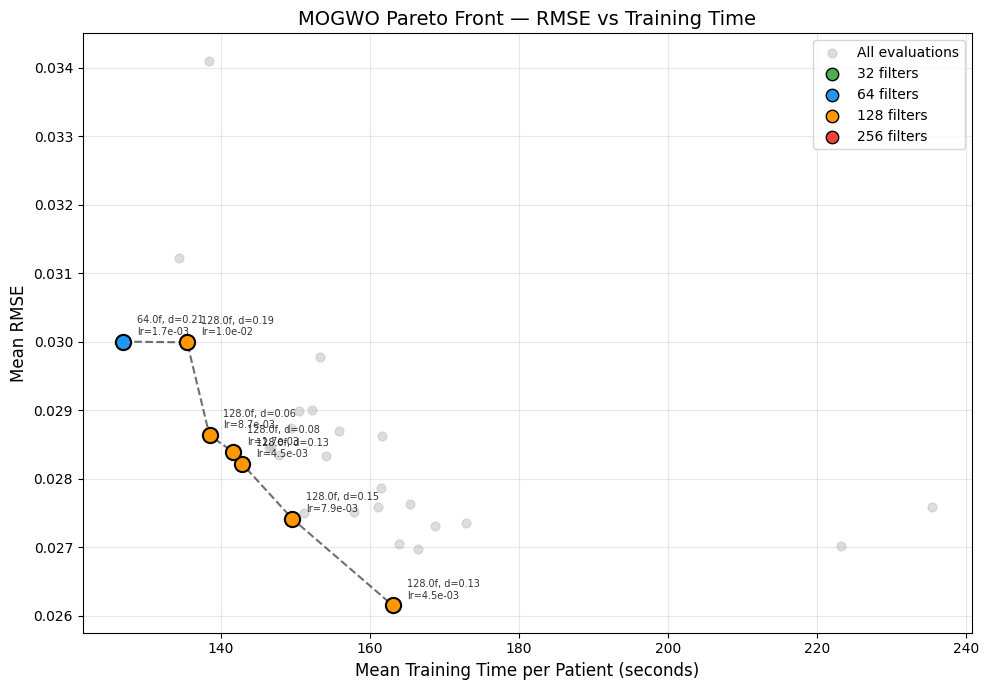

↑ Pareto front: points on the line are non-dominated (no solution is better on BOTH objectives).
  Pick your preferred tradeoff for the full evaluation notebook.


In [13]:
# ── 8.3 Pareto Front Plot ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))

# All evaluations (grey)
ax.scatter(df_evals['mean_time'], df_evals['mean_rmse'],
           c='#BDBDBD', s=40, alpha=0.5, label='All evaluations', zorder=1)

# Pareto front (coloured by n_filters)
colors_map = {32: '#4CAF50', 64: '#2196F3', 128: '#FF9800', 256: '#F44336'}
for _, row in df_archive.iterrows():
    c = colors_map.get(row['n_filters'], '#000000')
    ax.scatter(row['Time_s'], row['RMSE'], c=c, s=120, edgecolors='black',
              linewidths=1.5, zorder=3)

# Pareto front line (connect sorted archive points)
df_front = df_archive.sort_values('Time_s')
ax.plot(df_front['Time_s'], df_front['RMSE'], '--', color='#333333',
        linewidth=1.5, alpha=0.7, zorder=2)

# Legend for filter sizes
for filt, color in colors_map.items():
    ax.scatter([], [], c=color, s=80, edgecolors='black',
              linewidths=1, label=f'{filt} filters')

# Annotate archive points
for i, (_, row) in enumerate(df_archive.iterrows()):
    ax.annotate(f'{row["n_filters"]}f, d={row["dropout"]:.2f}\nlr={row["lr"]:.1e}',
               (row['Time_s'], row['RMSE']),
               textcoords='offset points', xytext=(10, 5),
               fontsize=7, alpha=0.8)

ax.set_xlabel('Mean Training Time per Patient (seconds)', fontsize=12)
ax.set_ylabel('Mean RMSE', fontsize=12)
ax.set_title('MOGWO Pareto Front — RMSE vs Training Time', fontsize=14)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/mogwo_pareto_front.png', dpi=200, bbox_inches='tight')
plt.show()

print('↑ Pareto front: points on the line are non-dominated (no solution is better on BOTH objectives).')
print('  Pick your preferred tradeoff for the full evaluation notebook.')

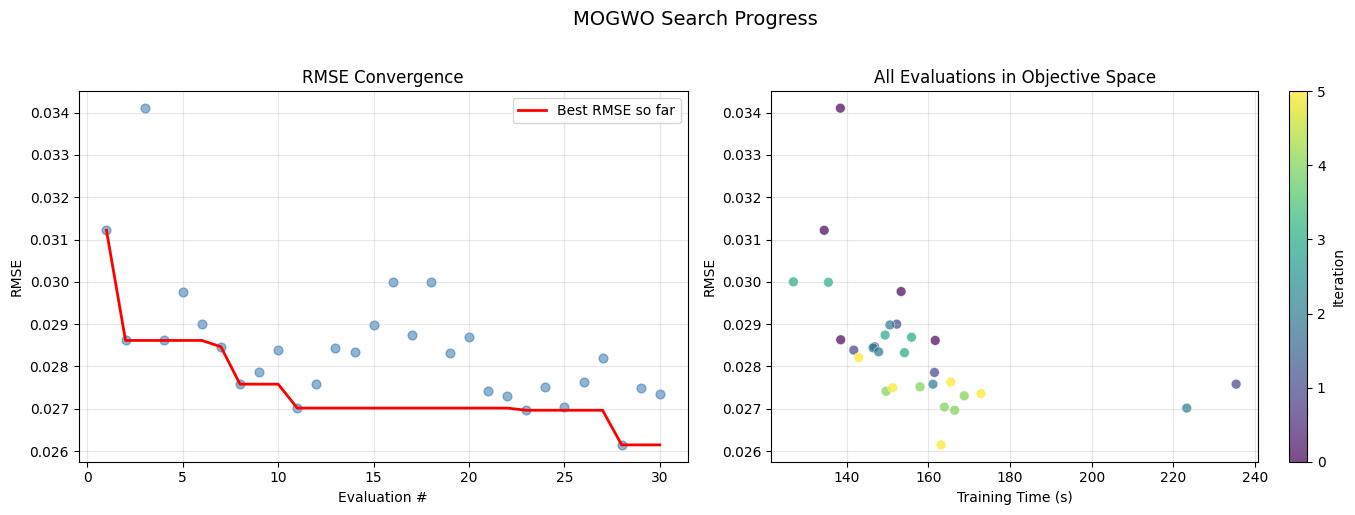

In [14]:
# ── 8.4 Convergence — Archive size & best RMSE over iterations ────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Build per-iteration stats from eval_history
iter_stats = []
best_rmse_so_far = float('inf')
for entry in eval_history:
    rmse_val = entry['objectives'][0]
    best_rmse_so_far = min(best_rmse_so_far, rmse_val)
    iter_stats.append({
        'eval_num': len(iter_stats) + 1,
        'iteration': entry['iteration'],
        'rmse': rmse_val,
        'time': entry['objectives'][1],
        'best_rmse': best_rmse_so_far,
    })
df_stats = pd.DataFrame(iter_stats)

# Plot 1: All evaluations over time (RMSE)
ax = axes[0]
ax.scatter(df_stats['eval_num'], df_stats['rmse'],
           alpha=0.6, s=40, c='steelblue')
ax.plot(df_stats['eval_num'], df_stats['best_rmse'],
        'r-', linewidth=2, label='Best RMSE so far')
ax.set_xlabel('Evaluation #')
ax.set_ylabel('RMSE')
ax.set_title('RMSE Convergence')
ax.legend()
ax.grid(alpha=0.3)

# Plot 2: RMSE vs Time for all evals, coloured by iteration
ax = axes[1]
sc = ax.scatter(df_stats['time'], df_stats['rmse'],
                c=df_stats['iteration'], cmap='viridis',
                s=50, alpha=0.7, edgecolors='white', linewidths=0.5)
plt.colorbar(sc, ax=ax, label='Iteration')
ax.set_xlabel('Training Time (s)')
ax.set_ylabel('RMSE')
ax.set_title('All Evaluations in Objective Space')
ax.grid(alpha=0.3)

plt.suptitle('MOGWO Search Progress', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('/kaggle/working/mogwo_convergence.png', dpi=200, bbox_inches='tight')
plt.show()

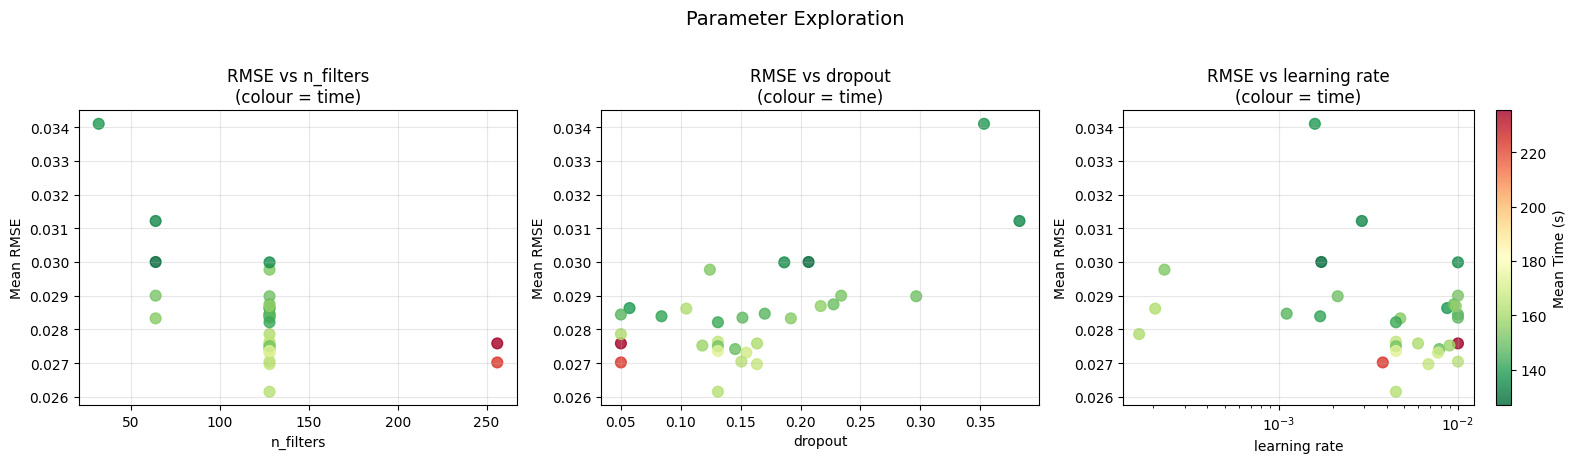

In [15]:
# ── 8.5 Parameter distributions ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, col, label in zip(axes,
    ['n_filters', 'dropout', 'lr'],
    ['n_filters', 'dropout', 'learning rate']):

    sc = ax.scatter(df_evals[col], df_evals['mean_rmse'],
                    c=df_evals['mean_time'], cmap='RdYlGn_r',
                    s=60, alpha=0.8)
    ax.set_xlabel(label)
    ax.set_ylabel('Mean RMSE')
    ax.set_title(f'RMSE vs {label}\n(colour = time)')
    ax.grid(alpha=0.3)
    if col == 'lr':
        ax.set_xscale('log')

plt.colorbar(sc, ax=axes[-1], label='Mean Time (s)')
plt.suptitle('Parameter Exploration', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('/kaggle/working/mogwo_param_distributions.png', dpi=200, bbox_inches='tight')
plt.show()

In [16]:
# ── 8.6 Comparison with previous GWO (single-objective) ──────────────────────
print('Previous GWO (single-objective) best:')
print('  n_filters=256, dropout=0.109, lr=0.002066')
print('  Pilot RMSE=0.026152, ~400-700s per patient (full eval)')
print()
print('MOGWO Pareto archive:')
for i, (_, row) in enumerate(df_archive.iterrows()):
    print(f'  [{i+1}] filters={row["n_filters"]:>3d}, '
          f'dropout={row["dropout"]:.3f}, lr={row["lr"]:.6f} '
          f'→ RMSE={row["RMSE"]:.6f}, Time={row["Time_s"]:.1f}s')

Previous GWO (single-objective) best:
  n_filters=256, dropout=0.109, lr=0.002066
  Pilot RMSE=0.026152, ~400-700s per patient (full eval)

MOGWO Pareto archive:


ValueError: Unknown format code 'd' for object of type 'float'

## 9 — Save Results

Save Pareto archive and full evaluation log for the next notebook to fetch.

In [ ]:
# ── Output directory (Kaggle) ─────────────────────────────────────────────────
OUT_DIR = '/kaggle/working'

# ── Save Pareto archive ──────────────────────────────────────────────────────
archive_path = os.path.join(OUT_DIR, 'mogwo_pareto_archive.csv')
df_archive.to_csv(archive_path, index=False)
print(f'Pareto archive saved to {archive_path} ({len(df_archive)} solutions)')

# ── Save full evaluation log ─────────────────────────────────────────────────
evals_path = os.path.join(OUT_DIR, 'mogwo_all_evaluations.csv')
df_evals.to_csv(evals_path, index=False)
print(f'All evaluations saved to {evals_path} ({len(df_evals)} evals)')

# ── Print summary for next notebook ──────────────────────────────────────────
print(f'\n{"="*70}')
print('MOGWO SEARCH COMPLETE — SUMMARY')
print(f'{"="*70}')
print(f'\nOptimiser      : MOGWO (Mirjalili et al. 2016)')
print(f'Objectives     : minimize RMSE, minimize training time')
print(f'Search space   : 3 params (n_filters, dropout, lr)')
print(f'Fixed          : n_blocks={FIXED_N_BLOCKS}, kernel={FIXED_KERNEL_SIZE}, batch={FIXED_BATCH_SIZE}')
print(f'Population     : {POP_SIZE} wolves × {MAX_ITER} iterations')
print(f'Total evals    : {len(mogwo_eval_log)}')
print(f'Total time     : {total_time/60:.1f} min')
print(f'Archive size   : {len(archive_solutions)} Pareto-optimal solutions')
print(f'\nPareto Archive (sorted by RMSE):')
print(f'  Best RMSE    : {df_archive["RMSE"].min():.6f} (time={df_archive.loc[df_archive["RMSE"].idxmin(), "Time_s"]:.1f}s)')
print(f'  Fastest      : {df_archive["Time_s"].min():.1f}s (RMSE={df_archive.loc[df_archive["Time_s"].idxmin(), "RMSE"]:.6f})')
print(f'\nAll output saved to {OUT_DIR}/:')
print(f'  mogwo_pareto_archive.csv   — fetch this in the evaluation notebook')
print(f'  mogwo_all_evaluations.csv  — full search log')
print(f'  mogwo_pareto_front.png')
print(f'  mogwo_convergence.png')
print(f'  mogwo_param_distributions.png')
print(f'{"="*70}')